Perform QA/QC on aerosol level 1 data and store as level 2 .parquet files.

Aggregate level 2 data and store as .parquet files.

[TODO] Generate submission-ready files.

In [7]:
import os
import polars as pl
%matplotlib ipympl

AE33 initialized.


statistic,dtm,BC1,BC2,BC3,BC4,BC5,BC6,BC7
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""67747""",67747.0,67747.0,67747.0,67747.0,67747.0,67747.0,67747.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2022-12-28 13:…",319.378349,311.65132,303.669166,283.030643,271.259347,259.210223,262.128995
"""std""",null,807.476997,837.536997,9157.289968,796.073982,774.316739,775.879054,789.571648
"""min""","""2021-07-04 14:…",-3014.0,-2512.0,-763647.0,-2282.0,-2390.0,-4036.0,-4005.0
"""25%""","""2022-12-14 11:…",34.0,33.0,32.0,30.0,27.0,23.0,21.0
"""50%""","""2022-12-29 15:…",168.0,157.0,148.0,139.0,132.0,129.0,128.0
"""75%""","""2023-01-10 09:…",358.0,335.0,313.0,292.0,279.0,273.0,275.0
"""max""","""2023-01-28 19:…",11762.0,13371.0,1.583972e6,13615.0,14684.0,18197.0,19552.0


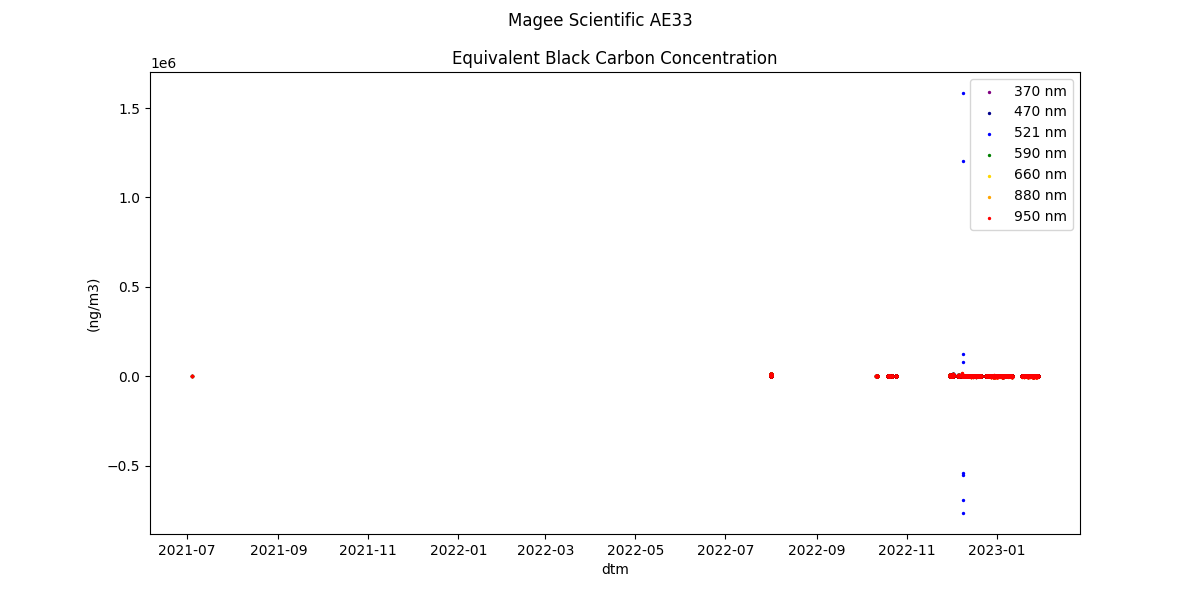

statistic,dtm,flags_BC1,flags_BC2,flags_BC3,flags_BC4,flags_BC5,flags_BC6,flags_BC7
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""67747""",67747.0,67747.0,67747.0,67747.0,67747.0,67747.0,67747.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2022-12-28 13:…",0.001978,0.002052,0.00217,0.001948,0.001993,0.00152,0.002007
"""std""",null,null,null,null,null,null,null,null
"""min""","""2021-07-04 14:…",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""","""2022-12-14 11:…",null,null,null,null,null,null,null
"""50%""","""2022-12-29 15:…",null,null,null,null,null,null,null
"""75%""","""2023-01-10 09:…",null,null,null,null,null,null,null
"""max""","""2023-01-28 19:…",1.0,1.0,1.0,1.0,1.0,1.0,1.0


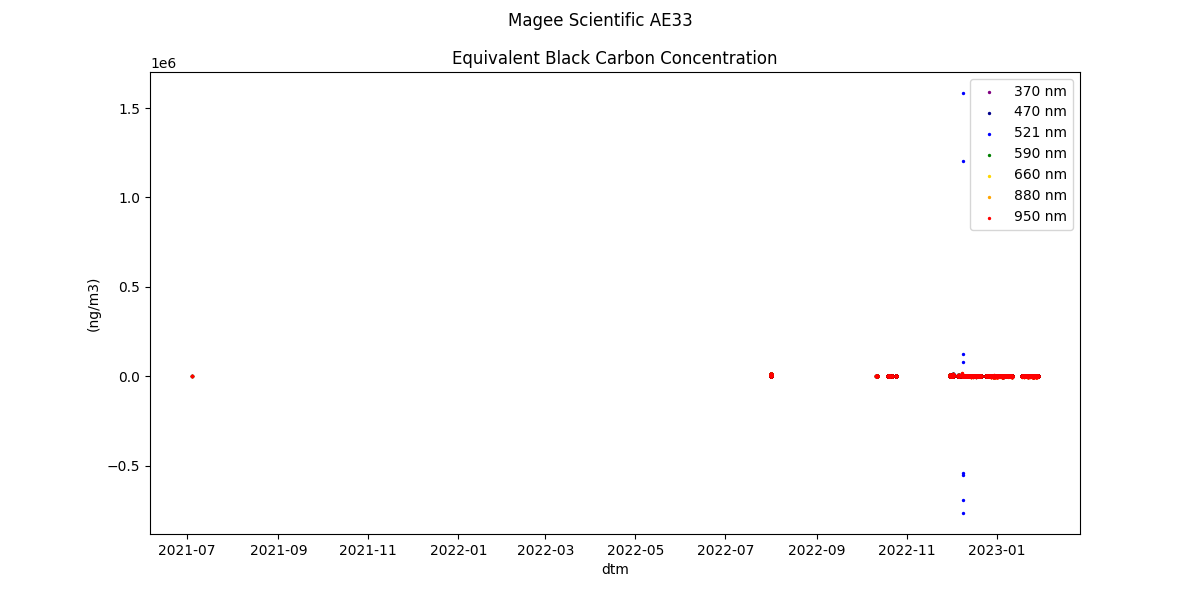

In [8]:
# AE33
from processing.ae33 import AE33
ae33 = AE33()

year = "2023"
month = "01"
source = os.path.join(os.getcwd(), "data/level1", year, month, "ae33.parquet")
df = pl.read_parquet(source=source)

cols = ["dtm", "BC1", "BC2", "BC3", "BC4", "BC5", "BC6", "BC7"]
display(df.select(cols).describe())

ae33.plot_aethalometer_data(df)

df_flagged = ae33.flag_spurious_data(df)
cols_flags = ["dtm", "flags_BC1", "flags_BC2", "flags_BC3", "flags_BC4", "flags_BC5", "flags_BC6", "flags_BC7"]
display(df_flagged.select(cols_flags).describe())
ae33.plot_aethalometer_data(df_flagged)

In [ ]:

# df, cutoffs = ae33.remove_extremes(df, q=0.00001)
# display(cutoffs)
# Filter the DataFrame to include only rows where 'spurious_flag' is False
# filtered_df = df.filter(df['flags'] == False)

# ae33.plot_aethalometer_data(df, start="2023-10-01", end="2023-10-31")